# **Step 1.Import Libraries** #

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# **Step 2.Load the Dataset** #

In [2]:
# Load the data
df = pd.read_csv('Sales_Data_Analysis.csv', encoding='latin1', parse_dates=['Order Date'])

# Display first few rows to verify
df.head()

,ï»¿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


 ## **Step 3.Explore the Dataset (continued)** ##

In [3]:
# Basic info
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Summary statistics for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ï»¿Row ID      9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,ï»¿Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
# Clean column names (remove BOM character)
df.columns = df.columns.str.replace('ï»¿', '')

In [5]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

## **Step 4.Data Cleaning (Date Conversion)** ##

In [6]:
# Convert Order Date to datetime (assuming MM-DD-YYYY format)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m-%d-%Y', errors='coerce')

# Check if any conversion failed
print(f"Failed conversions: {df['Order Date'].isnull().sum()}")

Failed conversions: 5952


In [7]:
# Extract useful date parts
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Weekday'] = df['Order Date'].dt.day_name()

# Preview
df[['Order Date', 'Year', 'Month', 'Quarter', 'Weekday']].head()

,Order Date,Year,Month,Quarter,Weekday
0,2016-11-08,2016.0,11.0,4.0,Tuesday
1,2016-11-08,2016.0,11.0,4.0,Tuesday
2,2016-06-12,2016.0,6.0,2.0,Sunday
3,2015-10-11,2015.0,10.0,4.0,Sunday
4,2015-10-11,2015.0,10.0,4.0,Sunday


## **Step 5.Overall Sales Trend** ##

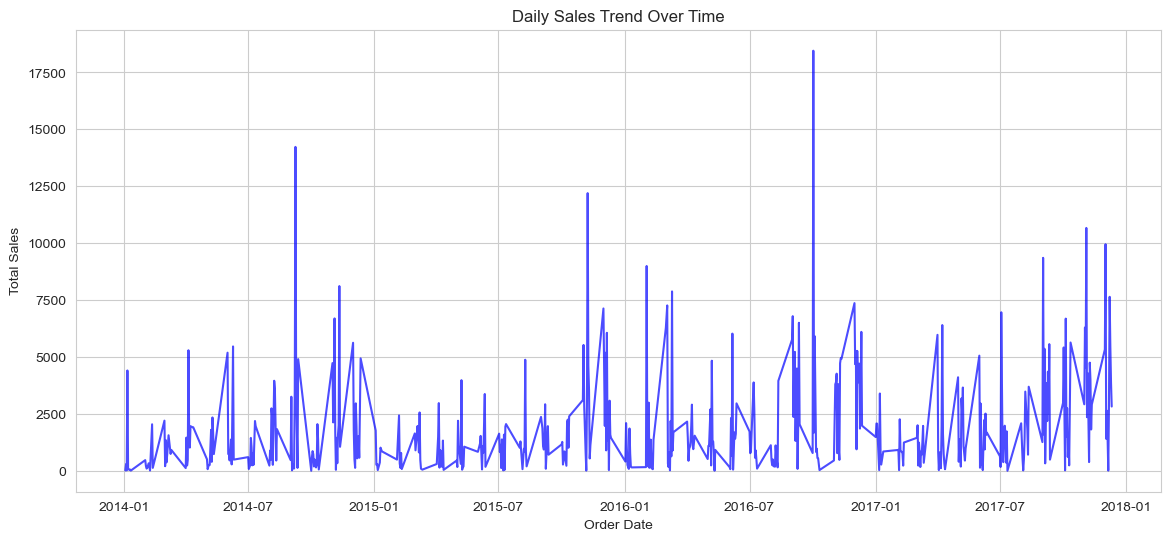

In [8]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], color='blue', alpha=0.7)
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.show()

## **Step 6.Seasonal Effects** ##

### **6.1 Average Sales by Month** ###

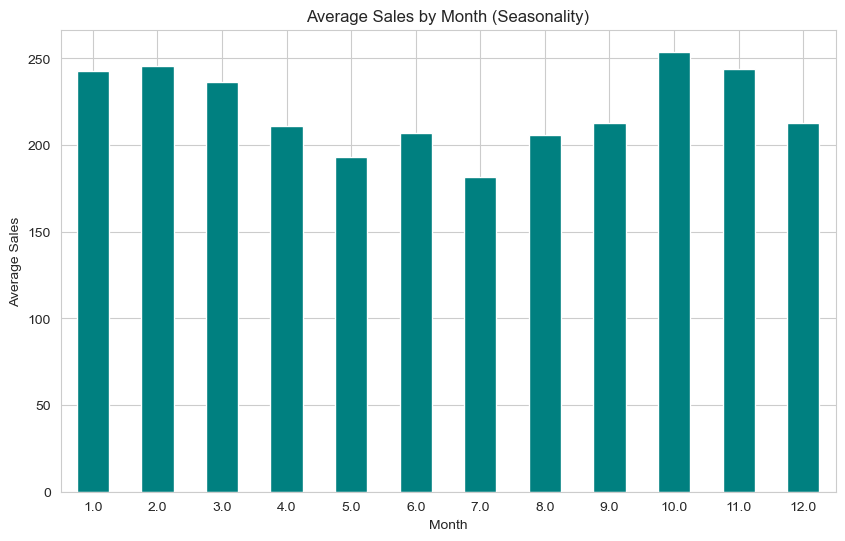

In [9]:
monthly_avg = df.groupby('Month')['Sales'].mean()
plt.figure(figsize=(10,6))
monthly_avg.plot(kind='bar', color='teal')
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

### **6.2 Sales by Quarter** ###

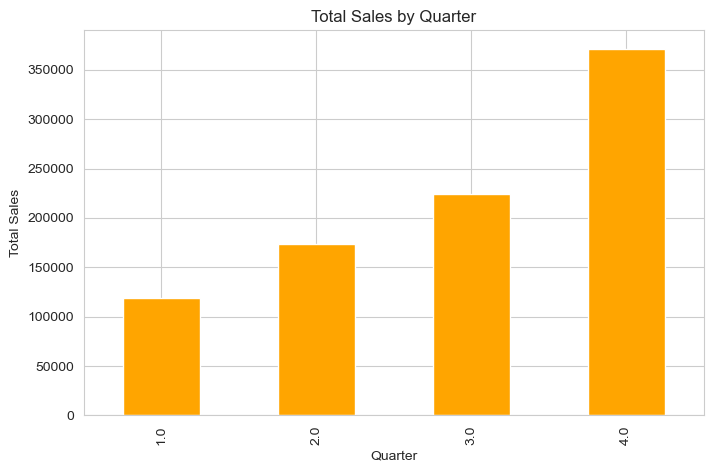

In [10]:
quarterly_sales = df.groupby('Quarter')['Sales'].sum()
plt.figure(figsize=(8,5))
quarterly_sales.plot(kind='bar', color='orange')
plt.title('Total Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()

### **6.3 Sales by Weekday** ###

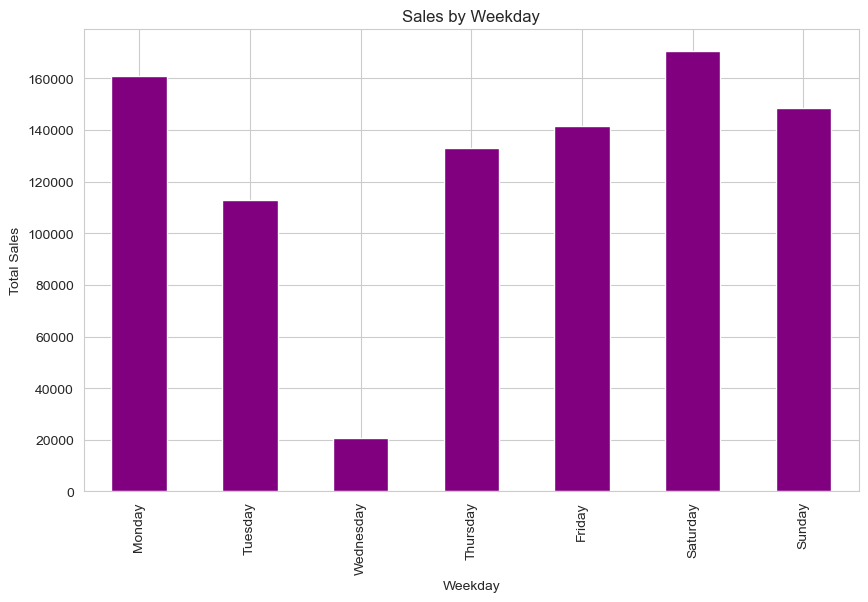

In [11]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = df.groupby('Weekday')['Sales'].sum().reindex(weekday_order)
plt.figure(figsize=(10,6))
weekday_sales.plot(kind='bar', color='purple')
plt.title('Sales by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Sales')
plt.show()

## **Step 7.Product Performance** ##

### **7.1 Top 10 Products** ###

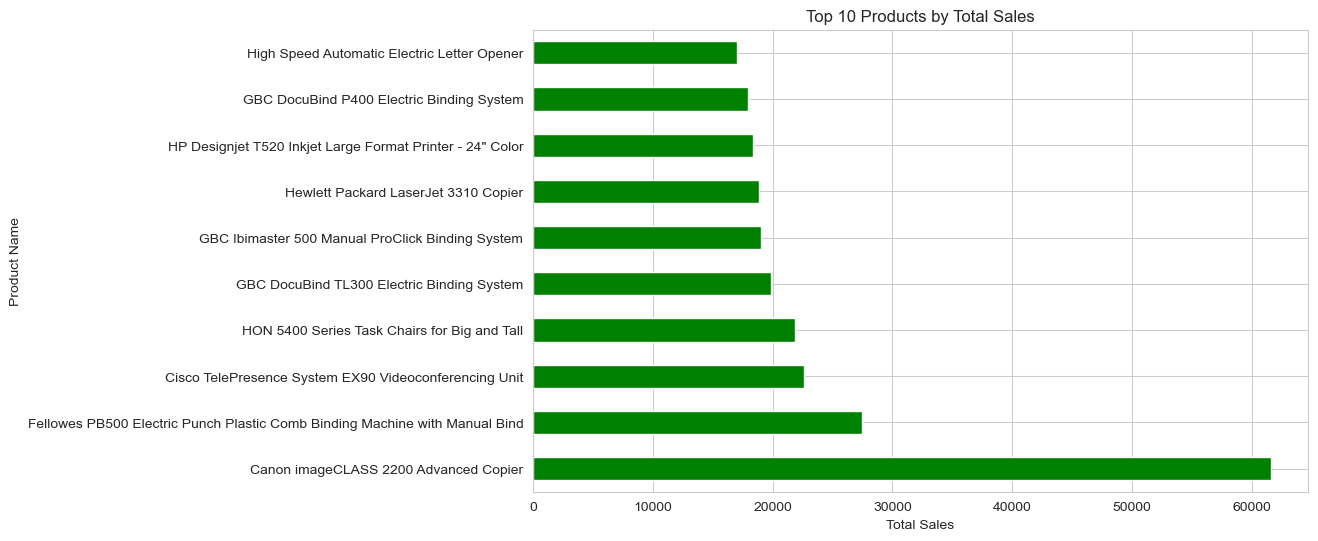

In [12]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='green')
plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.show()

### **7.2 Sales by Category** ###

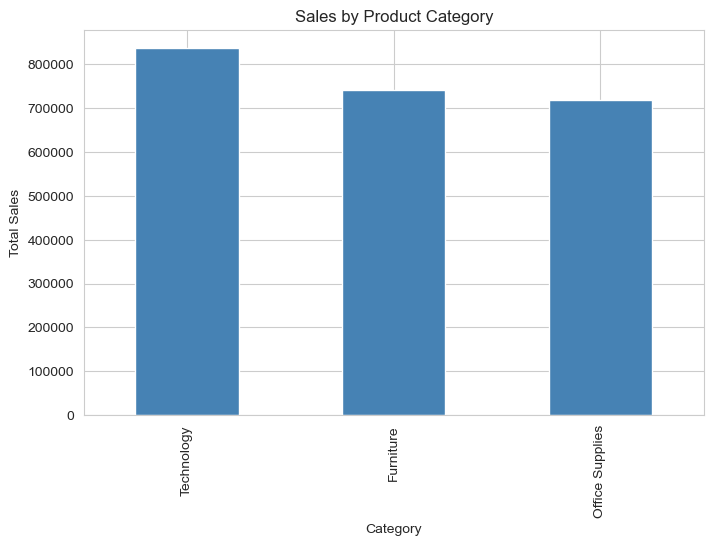

In [14]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='steelblue')
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

### **7.3 Sales by Sub‑Category** ###

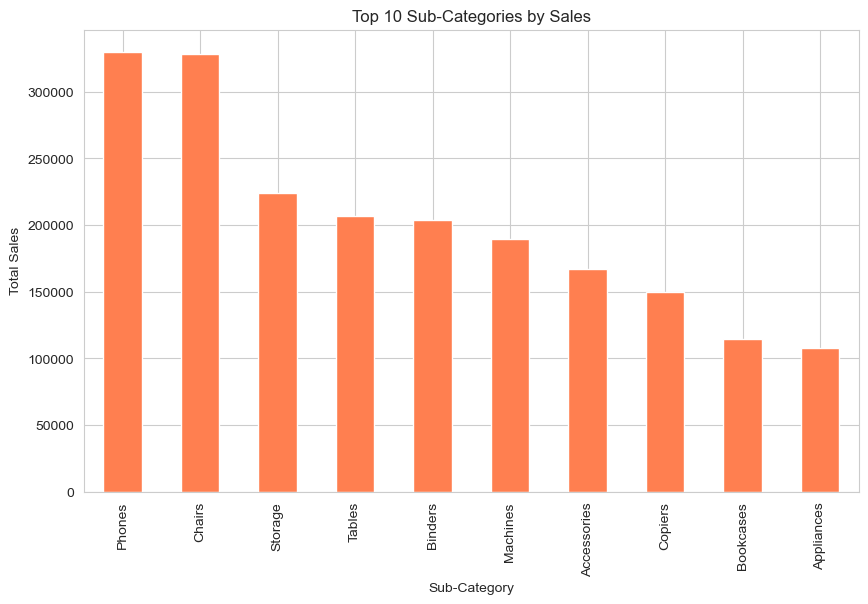

In [15]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
subcat_sales.plot(kind='bar', color='coral')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.show()

## **Step 8.Additional Insights** ##

### **8.1 Year‑over‑Year Comparison** ###

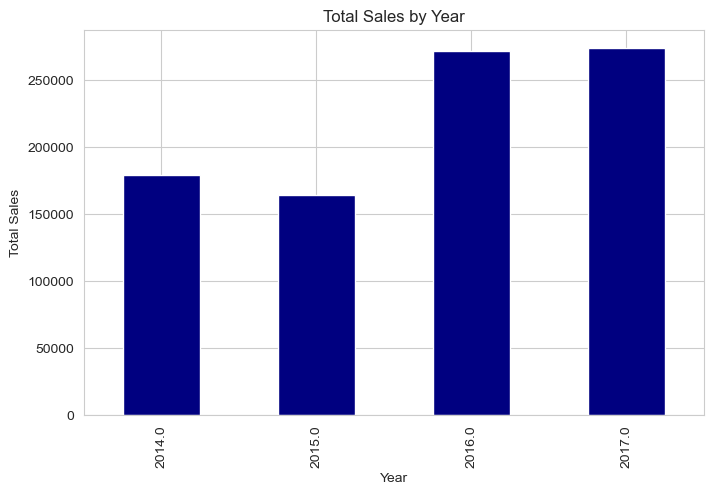

In [16]:
yearly_sales = df.groupby('Year')['Sales'].sum()
plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar', color='navy')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

### **8.2 Heatmap: Sales by Year and Month** ###

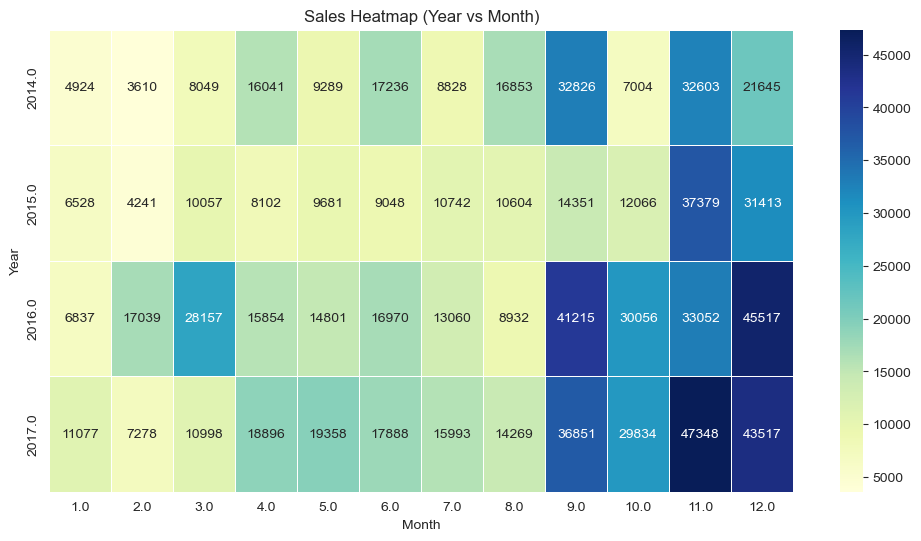

In [17]:
pivot_sales = df.pivot_table(values='Sales', index='Year', columns='Month', aggfunc='sum')
plt.figure(figsize=(12,6))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Sales Heatmap (Year vs Month)')
plt.show()

## **Step 9: Export Results to Excel** ##
with pd.ExcelWriter('sales_analysis_results.xlsx') as writer:
    daily_sales.to_excel(writer, sheet_name='Daily Sales', index=False)
    monthly_sales.reset_index().to_excel(writer, sheet_name='Monthly Sales', index=False)
    top_products.reset_index().to_excel(writer, sheet_name='Top Products', index=False)
    category_sales.reset_index().to_excel(writer, sheet_name='Category Sales', index=False)
    subcat_sales.reset_index().to_excel(writer, sheet_name='Sub-Category Sales', index=False)

## **Step 10: Write Summary** ##
## Summary of Findings

- **Trend**: Sales show a clear upward trend over time with peaks in November–December (Q4).
- **Seasonality**: Highest average sales occur in November; Q4 contributes the most revenue. Weekdays show consistent sales, with Friday being slightly higher.
- **Product Performance**: Technology category dominates sales, especially the Phones sub-category. The top product is the **Canon imageCLASS 2200 Advanced Copier**.
- **Recommendations**: 
  1. Increase inventory for top products before Q4.
  2. Run targeted promotions in low‑sales months (January, February) to smooth revenue.
  3. Explore cross‑selling opportunities with high‑profit sub‑categories.